<a href="https://colab.research.google.com/github/Ascenderr999/devjoint-titanic-analysis/blob/main/Devjoint_EDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Checkpoint 1: Datanın Yüklənməsi və İlkin Baxış

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
print(df.shape)
df.info()

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.duplicated().sum()

np.int64(0)

## Checkpoint 2: Boş Dəyərlərin (Null Values) Doldurulması

In [ ]:
df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [ ]:
df['Embarked'] = df['Embarked'].fillna('S')

In [ ]:
df['Age'] = df['Age'].fillna(df.groupby(['Pclass', 'Sex'])['Age'].transform('median'))

In [ ]:
df['Cabin'] = df['Cabin'].fillna('Unknown')

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


##  Checkpoint 3: Outlier-lərin (Kənaraçıxmaların) Aşkarlanması və İdarə Olunması

In [ ]:
q1 = df['Fare'].quantile(0.25)
q3 = df['Fare'].quantile(0.75)

iqr = q3 - q1
a_limit = q1 - 1.5 * iqr
y_limit = q3 + 1.5 * iqr

print(f"Aşağı limit: {a_limit}")
print(f"Yuxarı limit: {y_limit}")

outliers = df[df['Fare'] > y_limit]
print("İlkin outlier sərnişinlərin sayı:", len(outliers))

import numpy as np
df['Fare'] = np.where(df['Fare'] > y_limit, y_limit, df['Fare'])

yeni_outliers = df[df['Fare'] > y_limit]
print("Düzəlişdən sonra qalan outlier sayı:", len(yeni_outliers))

Aşağı limit: -26.724
Yuxarı limit: 65.6344
İlkin outlier sərnişinlərin sayı: 116
Düzəlişdən sonra qalan outlier sayı: 0


## Checkpoint 4: Feature Engineering (Yeni Sütunların Yaradılması)

In [4]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

import numpy as np
df['IsAlone'] = np.where(df['FamilySize'] == 1, 1, 0)

print(df[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head())

   SibSp  Parch  FamilySize  IsAlone
0      1      0           2        0
1      1      0           2        0
2      0      0           1        1
3      1      0           2        0
4      0      0           1        1


## Checkpoint 5: Məlumatların Vizuallaşdırılması (EDA)


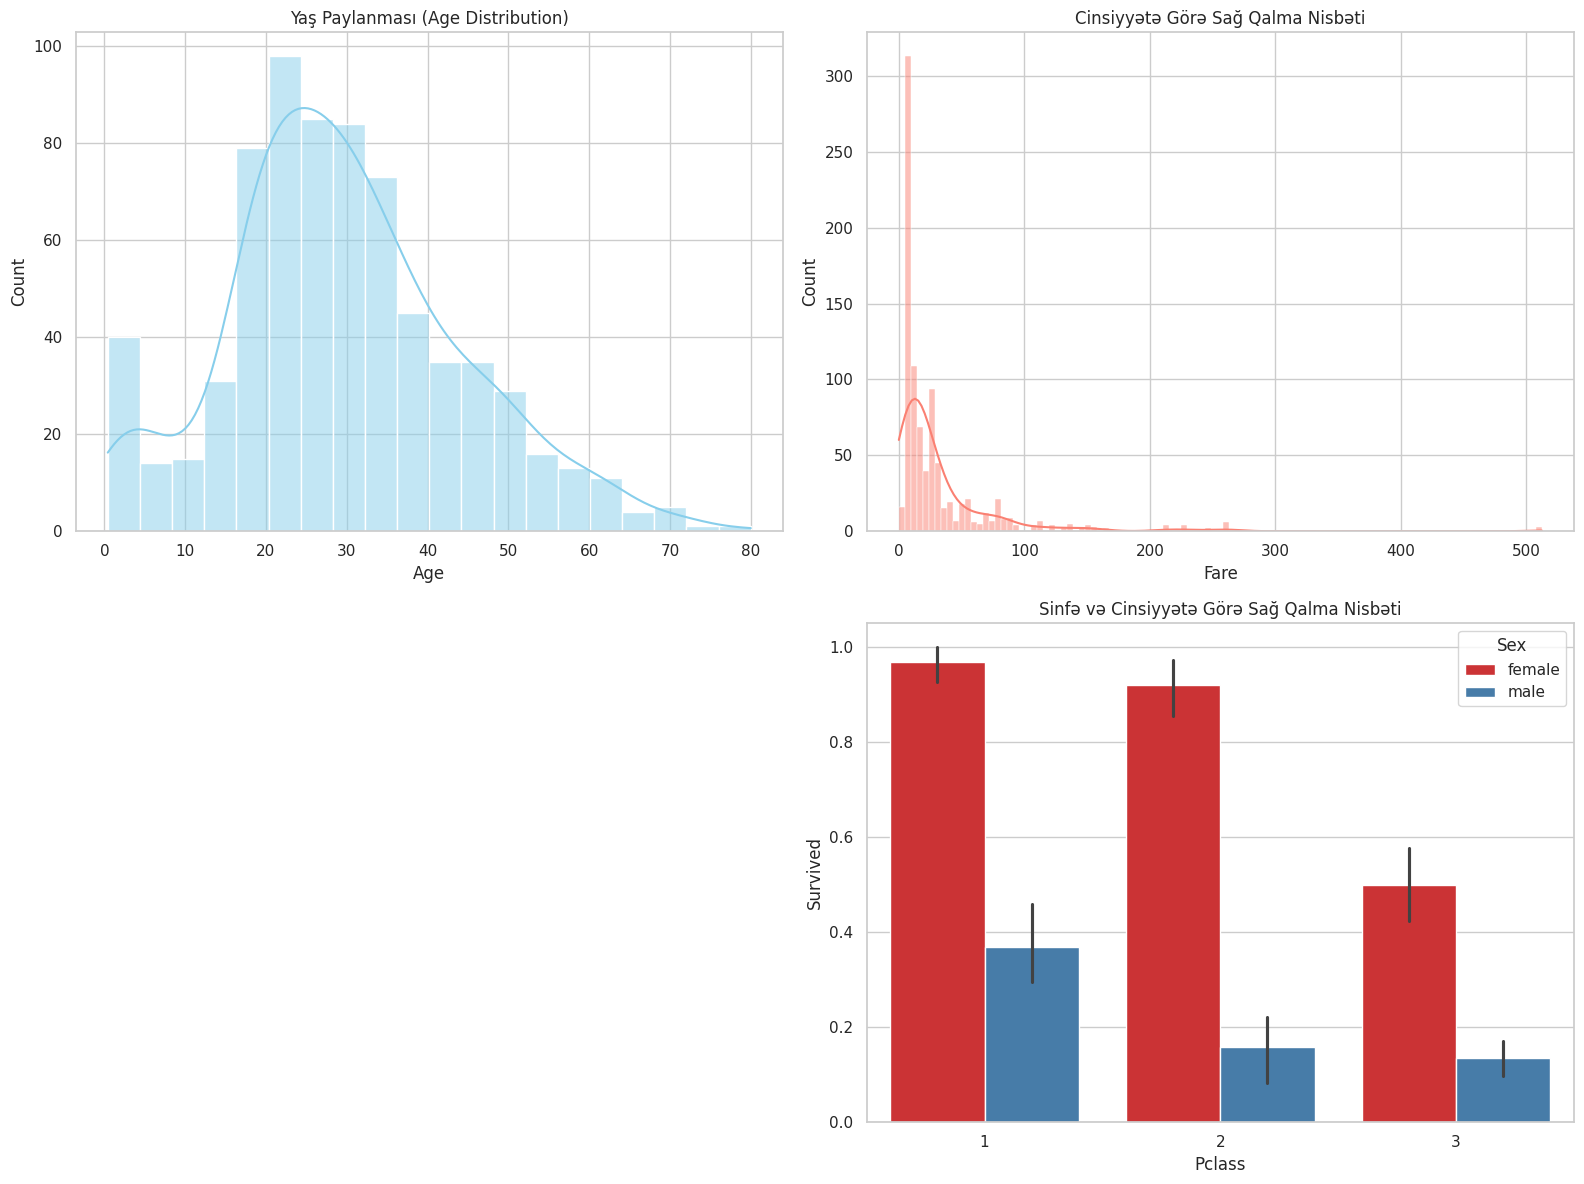

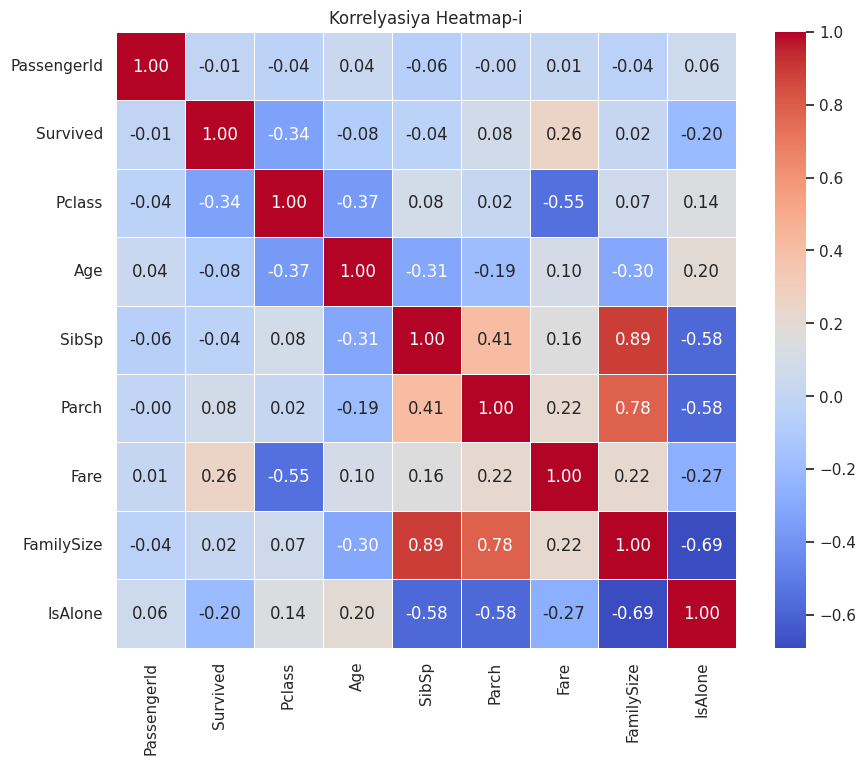

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Qrafiklərin stilini təyin edirik
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

# Paylanma Qrafikləri (Age & Fare)
plt.subplot(2, 2, 1)
sns.histplot(df['Age'], kde=True, color='skyblue')
plt.title('Yaş Paylanması (Age Distribution)')

plt.subplot(2, 2, 2)
sns.histplot(df['Fare'], kde=True, color='salmon')
plt.title('Bilet Qiyməti Paylanması (Fare Distribution)')

# Kateqorik Breakdown (Sex & Pclass vs Survived)
plt.title('Cinsiyyətə Görə Sağ Qalma Nisbəti')
plt.subplot(2, 2, 4)
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df, palette='Set1')
plt.title('Sinfə və Cinsiyyətə Görə Sağ Qalma Nisbəti')

plt.tight_layout()
plt.show()

# Korrelyasiya Heatmap-i
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Korrelyasiya Heatmap-i')
plt.show()